Jonathon Tucker Final Project

# Imports

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import re
import io

from IPython.display import display as ipy_display, Image as IPyImage
from torchvision import datasets, transforms

## Transformer and loading training data

In [2]:
transform = transforms.Compose([torchvision.transforms.ToTensor(), torchvision.transforms.Normalize((0.5,), (0.5,))]) #transform image data into tensors (mean 0.5 sd 0.5)

train_set = torchvision.datasets.MNIST(root='~/.pytorch/MNIST_data/', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=32, shuffle=True)

## Examine MNIST Data

In [3]:
#Examine Data Set
print('Number of images in the training dataset:', len(train_set))
print(f"Shape of the images in the training dataset: {train_loader.dataset[0][0].shape}")

Number of images in the training dataset: 60000
Shape of the images in the training dataset: torch.Size([1, 28, 28])


# Choose neural net. NN.sequential

In [4]:
input_size   = 784
hidden_sizes = [256, 128]
output_size  = 10

model = nn.Sequential(
    nn.Linear(input_size, hidden_sizes[0]),
    nn.ReLU(),
    nn.Linear(hidden_sizes[0], hidden_sizes[1]),
    nn.ReLU(),
    nn.Linear(hidden_sizes[1], output_size),
    nn.LogSoftmax(dim=1)
)
print(model)
# Forward pass through the network and display output
images, labels = next(iter(train_loader))
images.resize_(images.shape[0], 1, 784)
ps = model.forward(images[0,:])

# Print architecture summary and weights
linear_layers = [m for m in model if isinstance(m, nn.Linear)]
hidden_layers = linear_layers[:-1]

print(f'\nNumber of hidden layers: {len(hidden_layers)}')
print(f'Neurons per hidden layer: {[l.out_features for l in hidden_layers]}')
print()
for i, layer in enumerate(linear_layers):
    label = f'Hidden {i+1}' if i < len(hidden_layers) else 'Output'
    print(f'{label} layer weights shape: {layer.weight.shape}')
    print(layer.weight.data)
    print()

Sequential(
  (0): Linear(in_features=784, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=10, bias=True)
  (5): LogSoftmax(dim=1)
)

Number of hidden layers: 2
Neurons per hidden layer: [256, 128]

Hidden 1 layer weights shape: torch.Size([256, 784])
tensor([[-0.0056,  0.0191, -0.0027,  ..., -0.0277, -0.0305,  0.0005],
        [-0.0154,  0.0216, -0.0131,  ...,  0.0012,  0.0327, -0.0249],
        [-0.0103, -0.0334, -0.0206,  ...,  0.0231, -0.0162, -0.0018],
        ...,
        [ 0.0225,  0.0191,  0.0229,  ..., -0.0345,  0.0032,  0.0133],
        [ 0.0135, -0.0127,  0.0157,  ...,  0.0148,  0.0160, -0.0339],
        [ 0.0277, -0.0028,  0.0036,  ..., -0.0018, -0.0181, -0.0334]])

Hidden 2 layer weights shape: torch.Size([128, 256])
tensor([[ 0.0422, -0.0145,  0.0159,  ...,  0.0442,  0.0341,  0.0280],
        [ 0.0296,  0.0277,  0.0078,  ...,  0.0296,  0.0084, -0.0310],
       

# Train NN

In [5]:
# Training
loss_function = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


epochs = 15
for epoch in range(epochs):
    for images, labels in train_loader:
        optimizer.zero_grad()
        images = images.view(images.shape[0], -1) 
        output = model(images)
        loss = loss_function(output, labels)
        loss.backward()
        optimizer.step()
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [1/15], Loss: 0.1688
Epoch [2/15], Loss: 0.2772
Epoch [3/15], Loss: 0.1952
Epoch [4/15], Loss: 0.1005
Epoch [5/15], Loss: 0.0270
Epoch [6/15], Loss: 0.1675
Epoch [7/15], Loss: 0.1079
Epoch [8/15], Loss: 0.0084
Epoch [9/15], Loss: 0.0144
Epoch [10/15], Loss: 0.0395
Epoch [11/15], Loss: 0.0404
Epoch [12/15], Loss: 0.1038
Epoch [13/15], Loss: 0.0003
Epoch [14/15], Loss: 0.0037
Epoch [15/15], Loss: 0.0023


# Test Model

## Load Class Dataset

In [6]:
from pathlib import Path
from PIL import Image

path = Path('Handwritten-Digits-Spring-2026/digits')

# Define transform
pipe = transforms.Compose([transforms.Grayscale(1), transforms.Resize((28, 28)), 
                           transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# Filter and process
files = sorted([f for f in path.iterdir() if f.suffix.lower() in ('.png', '.jpg')])
images_list = [pipe(Image.open(f)).view(784) for f in files]
labels_list = [int(f.name.split('-')[0]) for f in files]

class_images = torch.stack(images_list)
class_labels = torch.tensor(labels_list)

print(f'Loaded {len(labels_list)} images; Shape: {class_images.shape}')
print('Label counts:', dict(zip(*np.unique(class_labels.numpy(), return_counts=True))))

Loaded 290 images; Shape: torch.Size([290, 784])
Label counts: {0: 29, 1: 29, 2: 29, 3: 29, 4: 29, 5: 29, 6: 29, 7: 29, 8: 29, 9: 29}


# Run against MNIST set

In [7]:
test_set = torchvision.datasets.MNIST(root='~/.pytorch/MNIST_data/', train = False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=64, shuffle = False)
model.eval()
correct = 0
total = 0
with torch.no_grad():
     for images, labels in test_loader:
         images = images.view(images.shape[0], -1)
         output = model(images)
         _, predicted = torch.max(output, 1)
         correct += (predicted == labels).sum().item()
         total += labels.size(0)

print(f'Accuracy on MNIST test set: {100 * correct / total:.2f}% ({correct}/{total})')

Accuracy on MNIST test set: 97.91% (9791/10000)


# Run against class set

In [8]:
# Run test on class dataset
model.eval()
with torch.no_grad():
    output = model(class_images)
    _, predicted = torch.max(output, 1)

correct = (predicted == class_labels).sum().item()
total = len(class_labels)
print(f'Accuracy on class dataset: {100 * correct / total:.2f}% ({correct}/{total})')
print()
print('Per-digit accuracy:')
for digit in range(10):
    mask = class_labels == digit
    if mask.sum() > 0:
        d_correct = (predicted[mask] == class_labels[mask]).sum().item()
        d_total = mask.sum().item()
        print(f'  Digit {digit}: {d_correct}/{d_total} ({100*d_correct/d_total:.1f}%)')

Accuracy on class dataset: 60.34% (175/290)

Per-digit accuracy:
  Digit 0: 16/29 (55.2%)
  Digit 1: 10/29 (34.5%)
  Digit 2: 21/29 (72.4%)
  Digit 3: 25/29 (86.2%)
  Digit 4: 20/29 (69.0%)
  Digit 5: 19/29 (65.5%)
  Digit 6: 21/29 (72.4%)
  Digit 7: 11/29 (37.9%)
  Digit 8: 18/29 (62.1%)
  Digit 9: 14/29 (48.3%)


In [9]:
from sklearn.metrics import f1_score, log_loss

y_true = class_labels.numpy()
y_pred = predicted.numpy()
probs  = torch.exp(output).numpy()

f1_macro = f1_score(y_true, y_pred, average='macro')
f1_per   = f1_score(y_true, y_pred, average=None)
print(f'F1 Score (macro): {f1_macro:.4f}')
print()
print('F1 per digit:')
for d, f in enumerate(f1_per):
    print(f'  Digit {d}: {f:.4f}')

print()
ll = log_loss(y_true, probs)
print(f'Log Loss: {ll:.4f}')

F1 Score (macro): 0.6137

F1 per digit:
  Digit 0: 0.7111
  Digit 1: 0.3390
  Digit 2: 0.6774
  Digit 3: 0.8197
  Digit 4: 0.6349
  Digit 5: 0.6230
  Digit 6: 0.7778
  Digit 7: 0.3056
  Digit 8: 0.7200
  Digit 9: 0.5283

Log Loss: 2.7512


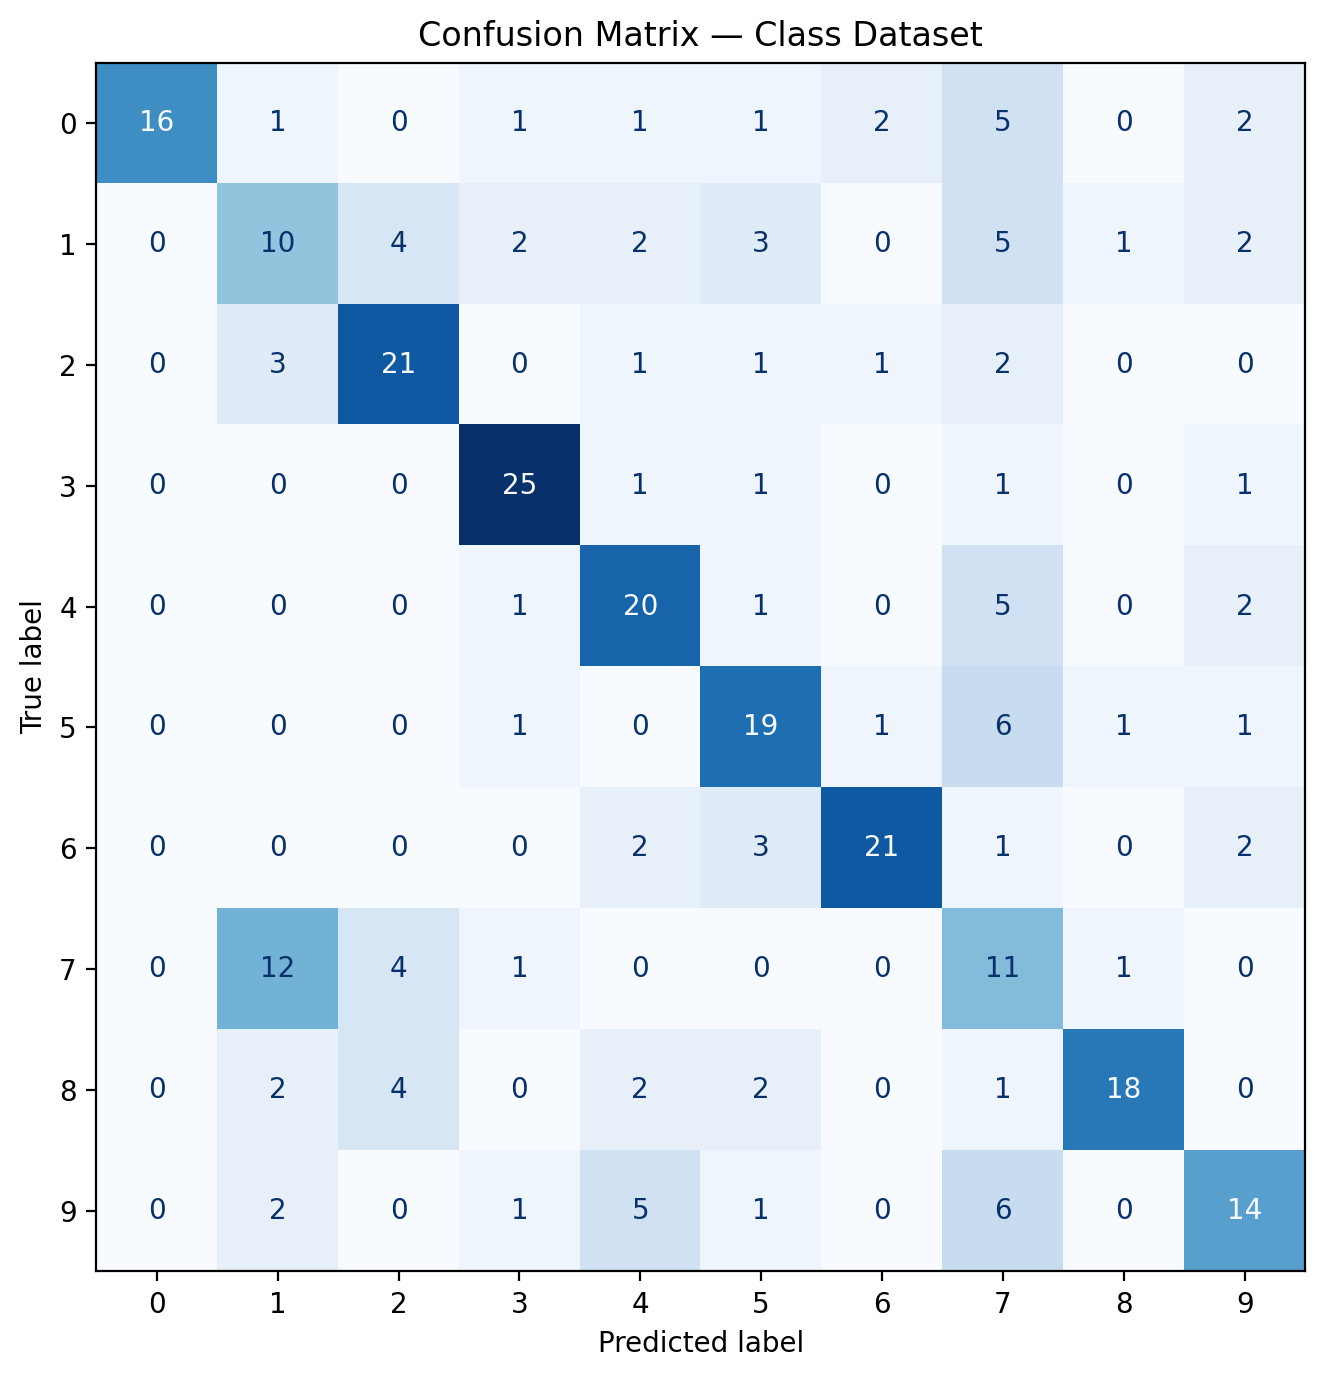

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Class Dataset')
plt.tight_layout()
plt.show()